### 11. (a) Demonstrate use of basic data augmentation for CIFAR-10 dataset. 

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Define basic data augmentation transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),       # Randomly flip images horizontally
    transforms.RandomCrop(32, padding=4),    # Randomly crop with padding
    transforms.ToTensor(),                   # Convert images to PyTorch tensors
    transforms.Normalize((0.5, 0.5, 0.5),     # Normalize R, G, B channels
                         (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [2]:
# 2. Load CIFAR-10 dataset with transformations
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=8,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)

testloader = torch.utils.data.DataLoader(testset, batch_size=8,
                                         shuffle=False, num_workers=2)

In [3]:
# 3. Define a function to visualize images
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

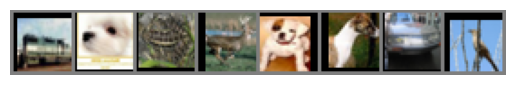

truck dog   frog  deer  dog   dog   car   bird 


In [4]:
# 4. Get a batch of training images and display
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images with data augmentation
imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))